# 🧠 Добро пожаловать в конспект ученика!
Представься, пожалуйста:

Тут тебя ждут практические задания для 5 и 6 урока курса летней школы МШП по Векторизации и построению RAG систем.

## Темы сегодняшнего урока:
## 5. Embeddings и 6. Семантический поиск.

Автор курса: Логинов Дмитрий Владимирович. Преподаватель и методист МШП, исследователь в области машинного обучения.

# 🧠 Небольшая памятка  по Embedding

## 💡 Идея

Компьютер не понимает слова.

Он понимает только числа.

Поэтому:

> любое слово нужно превратить в вектор (набор чисел)

---

## ❌ Проблема старого подхода

Если мы просто пронумеруем слова:

```text
кот = 1  
кошка = 2  
самолёт = 3
```

то компьютер думает:

```text
кот ≠ кошка
```

хотя они похожи 😿

---

## 💡 Идея embedding

Теперь вместо номера:

```text
кот = [0.2, -0.1, 0.8]
кошка = [0.21, -0.12, 0.79]
```

---

## 📌 Главное свойство

Похожие слова → похожие вектора

---

## 💻 Задание 1.
### 1. Загружаем модель

In [ ]:
!pip install gensim
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.6 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded


### 2. Найдём похожие слова

In [ ]:
model.most_similar("cat") # тут можно написать любое слово

[('dog', 0.9218006134033203),
 ('rabbit', 0.8487821221351624),
 ('monkey', 0.8041081428527832),
 ('rat', 0.7891963124275208),
 ('cats', 0.7865270972251892),
 ('snake', 0.7798910737037659),
 ('dogs', 0.7795814871788025),
 ('pet', 0.7792249917984009),
 ('mouse', 0.773166835308075),
 ('bite', 0.7728800177574158)]

### 3. Попробуем сами

In [ ]:
words = [] # Сюда впиши слова, которые тебя интересуют на английском языке.

for w in words:
    print(w, "→", model.most_similar(w, topn=3))

# 🧠 Небольшая памятка по скрытым признакам (latent features)

## 💡 Идея latent features

Embedding хранит скрытые признаки:

Например:

| координата | смысл (условно) |
|---|---|
| x1 | живое / неживое |
| x2 | домашнее / дикое |
| x3 | эмоция |
| x4 | размер |
| x5 | связано с людьми |

---

## 🌌 Геометрия смысла

```text
cat ●
        ● dog

              ● car
```

---

## 💻 Задание 2.
###1. Берём случайные слова

In [ ]:
words = [
    "", "", "", # в каждой строчке напиши по 3
    "", "", "", # близких по смыслу слова на английском
    "", "", ""
]

### 2. Создадим их векторы

In [ ]:
vectors = [model[w] for w in words]

vectors

[array([ 0.45281 , -0.50108 , -0.53714 , -0.015697,  0.22191 ,  0.54602 ,
        -0.67301 , -0.6891  ,  0.63493 , -0.19726 ,  0.33685 ,  0.7735  ,
         0.90094 ,  0.38488 ,  0.38367 ,  0.2657  , -0.08057 ,  0.61089 ,
        -1.2894  , -0.22313 , -0.61578 ,  0.21697 ,  0.35614 ,  0.44499 ,
         0.60885 , -1.1633  , -1.1579  ,  0.36118 ,  0.10466 , -0.78325 ,
         1.4352  ,  0.18629 , -0.26112 ,  0.83275 , -0.23123 ,  0.32481 ,
         0.14485 , -0.44552 ,  0.33497 , -0.95946 , -0.097479,  0.48138 ,
        -0.43352 ,  0.69455 ,  0.91043 , -0.28173 ,  0.41637 , -1.2609  ,
         0.71278 ,  0.23782 ], dtype=float32),
 array([ 0.11008  , -0.38781  , -0.57615  , -0.27714  ,  0.70521  ,
         0.53994  , -1.0786   , -0.40146  ,  1.1504   , -0.5678   ,
         0.0038977,  0.52878  ,  0.64561  ,  0.47262  ,  0.48549  ,
        -0.18407  ,  0.1801   ,  0.91397  , -1.1979   , -0.5778   ,
        -0.37985  ,  0.33606  ,  0.772    ,  0.75555  ,  0.45506  ,
        -1.7671   , -

### 3. Уменьшаем их размерность до 2D (в реальности, конечно, так никто не делает)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

### 4. Но мы сделаем, чтобы построить красивый график

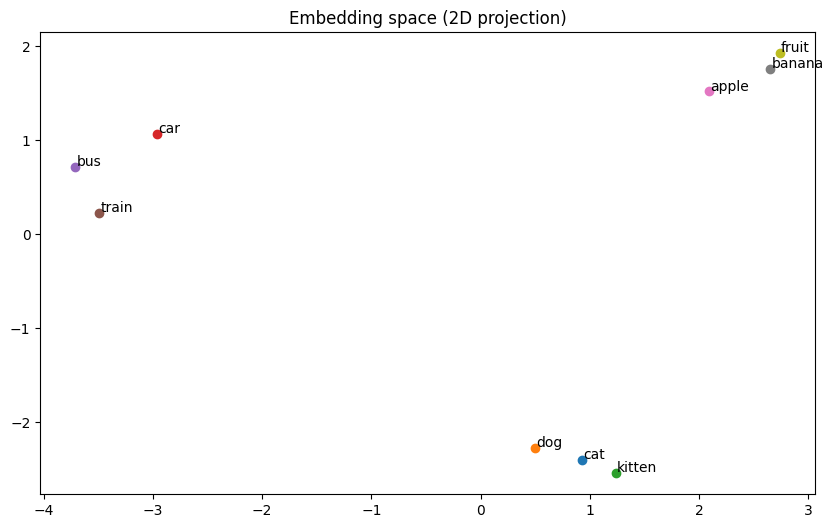

In [ ]:
plt.figure(figsize=(10,6))

for word, (x, y) in zip(words, coords):
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Embedding space (2D projection)")
plt.show()

# 🚀 Памятка по Word2Vec

## 💡 Главная идея

Мы НЕ говорим компьютеру смысл слов.

Мы заставляем его:

> угадывать слова по контексту

---

## 🤔 Пример

Фраза:

```text
cat sits on the sofa
```

---

Задача:

```text
cat sits on ___
```

---

Ответ:

```text
sofa
```

---

## 🪟 Контекстное окно

Берём только соседние слова:

```text
cat | sits | on | sofa
```

---

## 🔥 Две модели Word2Vec

---

# 1️⃣ CBOW

👉 угадываем слово по контексту

```text
cat ___ milk
→ drinks
```

---

# 2️⃣ Skip-gram

👉 угадываем контекст по слову

```text
cat → sits, sofa, milk
```

---


## 💻 Задание 3.
### 1. Опять эти похожие слова

In [ ]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

model.most_similar("") # сюда опять любое английское слово

[('prince', 0.8236179351806641),
 ('queen', 0.7839043140411377),
 ('ii', 0.7746230363845825),
 ('emperor', 0.7736247777938843),
 ('son', 0.766719400882721),
 ('uncle', 0.7627150416374207),
 ('kingdom', 0.7542160749435425),
 ('throne', 0.7539913654327393),
 ('brother', 0.7492411136627197),
 ('ruler', 0.7434253692626953)]

###2. Магия Word2Vec

In [ ]:
model.most_similar(
    positive=["king", "woman"], # тут тоже можешь поэксперементировать. Не бойся.
    negative=["man"]
)

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904),
 ('princess', 0.7424570322036743),
 ('kingdom', 0.7337412238121033),
 ('monarch', 0.721449077129364),
 ('eldest', 0.7184861898422241),
 ('widow', 0.7099431157112122)]

Как ты думаешь, почему именно первый ответ модели стал самым близким к запросу: postitve king, woman. negative = man?. Напиши свое мнение здесь.

###3. Поле для экспериментов. Тут реализуй любые свои идеи.

In [ ]:
words = ["pizza", "school", "computer", "music", "city"]

for w in words:
    print(w, ":", model.most_similar(w, topn=3))

pizza : [('sandwich', 0.8658444285392761), ('sandwiches', 0.8573424816131592), ('snack', 0.8139194846153259)]
school : [('college', 0.9344995617866516), ('schools', 0.868353009223938), ('campus', 0.8472232222557068)]
computer : [('computers', 0.9165045022964478), ('software', 0.8814992904663086), ('technology', 0.852556049823761)]
music : [('musical', 0.8853500485420227), ('pop', 0.868208110332489), ('dance', 0.853119969367981)]
city : [('town', 0.8687878251075745), ('downtown', 0.8534142374992371), ('where', 0.8525029420852661)]
